In [7]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import scipy.stats
import scipy.optimize

In [1]:
title = "# Introduction to Bayesian statistics: exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)
import numpy as np
import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Introduction to Bayesian statistics: exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

# Exercise 1

- Implement your own version of the line-fitting procedure, using the same data.
- Now try it with the data in `lectures/data/linear_fits/data_1.txt`
    - First plot the data. What has changed?
    - Try the same model and likelihood on the new data. You might want to adjust the prior on $m$ and $b$ for this new data set.
    - What if you use the provided uncertainty per data point $\sigma_{y_i}$, instead of assuming a constant variance $\sigma_y$ for all data points?
    - Instead use the actual likelihood of the data:
\begin{align}
    \mu(x) &= mx + b \\
    \sigma(x_i) &= \sigma_{y_i} + f\mu(x_i)^2 \quad f > 0\ \text{a parameter} \\
    y_i&\sim\mathcal N(\mu(x_i),\sigma(x_i)^2)
\end{align}
Careful with the normalisation of the Gaussian likelihood. Because we vary the variance, this matters now!

<ErrorbarContainer object of 3 artists>

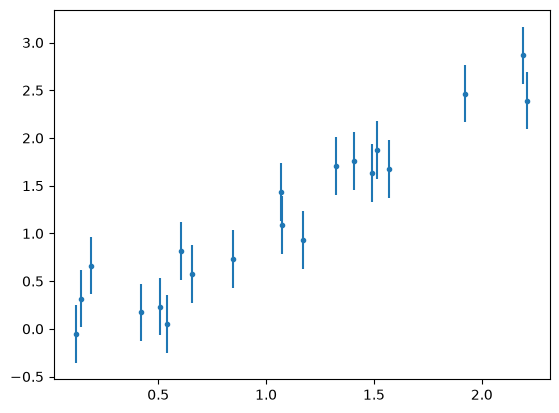

In [2]:
x, y, y_err = np.loadtxt('../lectures/data/linear_fits/data_0.txt', unpack=True)

plt.errorbar(x, y, y_err, fmt='.')

In [9]:
def lin_model(x:npt.NDArray[np.float32], m: float, b: float) -> npt.NDArray[np.float32]:
    return m * x + b

def log_likelihood(y: npt.NDArray[np.float32], x: npt.NDArray[np.float32], m: float, b: float, std_y: float) -> npt.NDArray[np.float32]:
    prediction = lin_model(x, m, b)
    n = len(y)
    return - n/2 * np.log(2 * np.pi * std_y**2) - 1/(2 * std_y ** 2) * np.sum((y-prediction)**2)

m_prior = scipy.stats.norm(loc=1, scale=1)
b_prior = scipy.stats.norm(loc=0, scale=1.2)

def log_prior(m: float, b: float):
    return m_prior.logpdf(m) + b_prior.logpdf(b)

def log_posterior(m: float, b: float, x: npt.NDArray[np.float32], std_y: float, y: npt.NDArray[np.float32]) -> npt.NDArray[np.float32]:
    return log_likelihood(y, x, m, b, std_y) + log_prior(m, b)

def neg_post(theta, x: npt.NDArray[np.float32], std_y: float, y: npt.NDArray[np.float32]) -> npt.NDArray[np.float32]:
    m, b = theta
    return - log_posterior(m, b, x, std_y, y)


std_y = y_err[0]

MAP_result = scipy.optimize.minimize(
    fun=neg_post,
    x0=(1,0),
    args=(x, std_y, y)
)

m_MAP, b_MAP = MAP_result.x
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")


m_MAP = 1.251, b_MAP = -0.145


Text(0, 0.5, 'y')

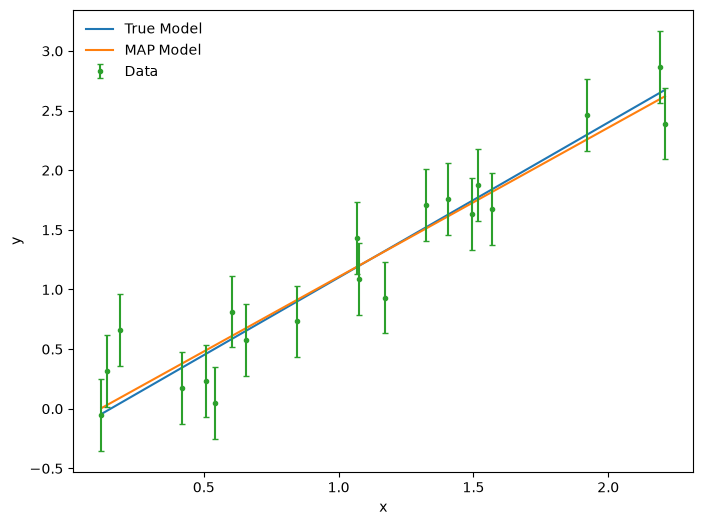

In [18]:
_, ax = plt.subplots(figsize=(8,6))

x_axis = np.linspace(x[0], x[-1], 100)
y_pred = lin_model(x_axis, m_MAP, b_MAP)


ax.plot(x_axis, lin_model(x_axis, 1.300, -.200), label='True Model')
ax.plot(x_axis, y_pred, label='MAP Model')

ax.errorbar(x, y, y_err, fmt='.', label='Data', capsize=2)

ax.legend(frameon=False)

ax.set_xlabel('x')
ax.set_ylabel('y')


# Exercise 2

The data in the previous example were a synthetic version of real observations that were obtained in an AstroWoche project in 2024 by Jonas Spiller, Theo Lequy, Clara Bleich. 

<!-- ![jovian moons data](../assets/jovian_moons_raw_data.png) -->
<img style="display: block; 
    margin-left: auto;
    margin-right: auto;
    width: 60%;"
    src="../assets/jovian_moons_raw_data.png" alt="jovian moons data"/>

The real observations can be found in `data/jovian_moons/{moon}.dat`:

In [4]:
moon = "Io"

t, distance, distance_alt, distance_err = np.loadtxt(
    f"../lectures/data/jovian_moons/{moon}.dat", unpack=True)

1. Repeat the analysis with the real data set. What do you find?

There is another distance estimate provided. The difference between the distance estimates comes from different approaches to converting the measured distance between Jupiter and its moons from the number of pixels to a physical distance in km.

2. How does the analysis look when using this other distance estimate (what I call `distance_alt`)? What about the other moons?



Because there are two distance estimates that do not agree, both of which are based on reasonable approaches, this suggests that there might be a _systematic_ error in the measurements. Systematic errors are usually not random (which means they do not get smaller as you obtain more data). But we could pretend the offset between the two measurements is an estimate of an unaccounted statistical uncertainty. 

3. How does the analysis look when we assume `sigma_d**2 = distance_err**2 + (distance - distance_alt)**2`?



4. Instead of assuming that the uncertainty is underestimated by this offset, we can also model it. Does the model work better if the variance is a free parameter?
